In [2]:
import os
from pathlib import Path
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from safetensors.torch import save_file, load_file  # tensor I/O [web:9]
from scipy.sparse.linalg import LinearOperator, svds  # operator + truncated SVD [web:47][web:38]

import matplotlib.pyplot as plt

In [3]:
import os, random
import numpy as np
import torch

def seed_everything(seed: int = 0, deterministic: bool = True):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed = 0
seed_everything(seed)


## Datasets

In [27]:
class Dataset(ABC):
    """
    Abstract base class for generating synthetic datasets.
    """
    def __init__(self, n_samples, in_dim, out_dim=1, noise=0.1, seed=42):
        if in_dim < 2:
            raise ValueError("in_dim must be at least 2 for this logic.")

        self.n_samples = n_samples
        self.in_dim = in_dim
        self.noise = noise
        self.rng = np.random.RandomState(seed)

        # As in your snippet: random dense ground-truth direction
        self.true_weights_mask = self.rng.randn(in_dim, 1)

    def _create_weight_mask(self, anisotropy_ratio=1e4, seed=42):
        rng = np.random.default_rng(seed)

        principal_weights = np.logspace(0, np.log10(anisotropy_ratio), self.in_dim)
        principal_weights *= rng.choice([-1, 1], size=self.in_dim)

        random_matrix = rng.standard_normal(size=(self.in_dim, self.in_dim))
        rotation_matrix, _ = np.linalg.qr(random_matrix)

        correlated_weights = rotation_matrix @ principal_weights
        return correlated_weights.reshape(-1, 1)

    @abstractmethod
    def create_data(self):
        pass

    def _generate_labels(self, X):
        logits = X @ self.true_weights_mask
        sigmoid = lambda z: 1 / (1 + np.exp(-z))
        probabilities = sigmoid(logits)
        y = (self.rng.uniform(size=probabilities.shape) < probabilities).astype(np.int64).flatten()
        return y

    def get_data_for_analysis(self):
        X_np, y_t = self.create_data()
        feature_names = [f'feature_{i}' for i in range(self.in_dim)]
        X_df = pd.DataFrame(X_np, columns=feature_names)
        return X_df, y_t


class IsotropicDataset(Dataset):
    def create_data(self):
        cov = np.eye(self.in_dim)
        X = self.rng.multivariate_normal(np.zeros(self.in_dim), cov, size=self.n_samples).astype(np.float32)
        y = self._generate_labels(X)
        return X, torch.tensor(y, dtype=torch.long)


class AnisotropicDataset(Dataset):
    def create_data(self):
        Z = self.rng.normal(loc=0.0, scale=1.0, size=(self.n_samples, self.in_dim))


        diag_vals = 1 + self.rng.uniform(0, 0.1, size=self.in_dim)
        sub_vals  = 1 + self.rng.uniform(0.1, 0.5, size=self.in_dim - 1)
    
        T = np.zeros((self.in_dim, self.in_dim), dtype=float)
        np.fill_diagonal(T, diag_vals.astype(float))


        T[np.arange(1, self.in_dim), np.arange(self.in_dim - 1)] = sub_vals.astype(float)
    
        X = Z @ T
    
        y = self._generate_labels(X)


        return torch.from_numpy(X).float(), torch.from_numpy(np.asarray(y)).long().flatten()


class CorrelatedToeplitzDataset(Dataset):
    def _toeplitz_ar1_cov(self, rho: float, scale: float = 1.0) -> np.ndarray:
        # Sigma[i,j] = scale^2 * rho^{|i-j|}  (Toeplitz AR(1)) [web:194]
        idx = np.arange(self.in_dim)
        Sigma = rho ** np.abs(idx[:, None] - idx[None, :])
        return (scale ** 2) * Sigma

    def _safe_cholesky(self, R: np.ndarray, eps0: float = 1e-12, max_tries: int = 8) -> np.ndarray:
        eps = eps0
        for _ in range(max_tries):
            try:
                return np.linalg.cholesky(R)
            except np.linalg.LinAlgError:
                R = R + eps * np.eye(R.shape[0])
                eps *= 10.0
        w, V = np.linalg.eigh(R)
        w = np.clip(w, 1e-10, None)
        R_spd = (V * w) @ V.T
        return np.linalg.cholesky(R_spd)

    def create_data(self, rho: float = 0.9, scale: float = 1.0):
        if not (-1.0 < rho < 1.0):
            raise ValueError("Need |rho| < 1 for AR(1) Toeplitz covariance to be SPD. [web:194]")

        # Target Toeplitz covariance
        Sigma = self._toeplitz_ar1_cov(rho=rho, scale=scale)

        # Cholesky factor (lower triangular): Sigma = L L^T
        L = self._safe_cholesky(Sigma)

        # Sample correlated Gaussian: if Z ~ N(0, I), then X = Z @ L^T has cov Sigma. [web:203]
        Z = self.rng.normal(loc=0.0, scale=1.0, size=(self.n_samples, self.in_dim)).astype(np.float32)
        X = (Z @ L.T).astype(np.float32)

        y = self._generate_labels(X)
        return torch.from_numpy(X), torch.from_numpy(np.asarray(y)).long().flatten()

    


Saving plot to: covariances.pdf


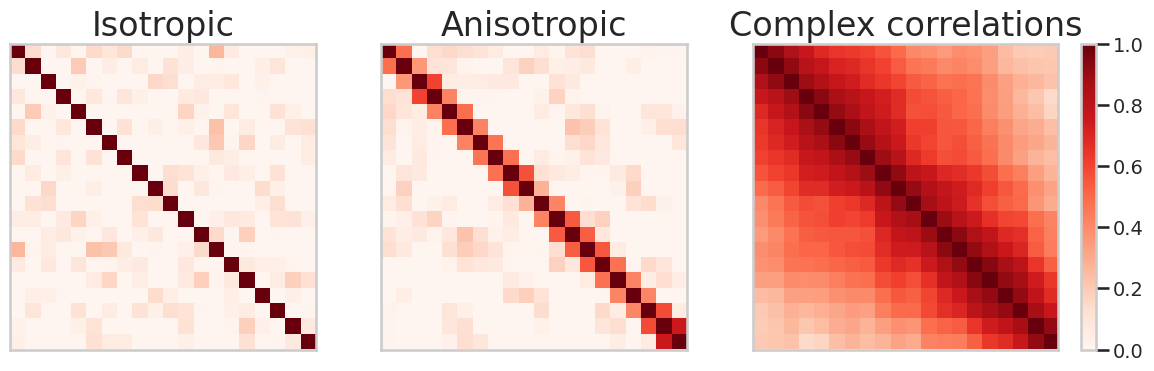

(<Figure size 1200x360 with 4 Axes>,
 array([<Axes: title={'center': 'Isotropic'}>,
        <Axes: title={'center': 'Anisotropic'}>,
        <Axes: title={'center': 'Complex correlations'}>], dtype=object),
 <matplotlib.colorbar.Colorbar at 0x7f2a7eb68450>)

In [38]:
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path

def plot_three_covariances_like_slide(
    cov_iso,
    cov_simple,
    cov_complex,
    titles=("Isotropic", "Anisotropic", "Complex correlations"),
    suptitle="X correlations: highly correlated features",
    vmin=0.0,
    vmax=1.0,
    # suptitle_fs=22,
    title_fs=24,
    cbar_tick_fs=14,
    savepath=None,  # new parameter
):
    covs = [cov_iso, cov_simple, cov_complex]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)
    # fig.suptitle(suptitle, fontsize=suptitle_fs)

    im = None
    for ax, cov, title in zip(axes, covs, titles):
        im = ax.imshow(cov, vmin=vmin, vmax=vmax, cmap="Reds", interpolation="nearest")
        ax.set_title(title, fontsize=title_fs)
        ax.set_xticks([])
        ax.set_yticks([])

    cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=cbar_tick_fs)

    # Save to PDF (or PNG)
    if savepath is not None:
        save_file = Path(savepath)
        save_file.parent.mkdir(parents=True, exist_ok=True)
        print(f"Saving plot to: {save_file}")
        fig.savefig(save_file, format="pdf", bbox_inches="tight", dpi=150)

    plt.show()
    return fig, axes, cbar




def empirical_corr_from_dataset(ds, eps=1e-12):
    X, _ = ds.create_data()
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    X = np.asarray(X, dtype=np.float64)

    Xc = X - X.mean(axis=0, keepdims=True)
    cov = (Xc.T @ Xc) / Xc.shape[0]
    d = np.sqrt(np.clip(np.diag(cov), eps, None))
    corr = cov / (d[:, None] * d[None, :])
    corr = np.clip(corr, 0.0, 1.0)
    return corr

# Example
in_dim = 20
n_samples = 100

iso = IsotropicDataset(n_samples=n_samples, in_dim=in_dim, seed=0)
simple = AnisotropicDataset(n_samples=n_samples, in_dim=in_dim, seed=0) 
complex_ds = CorrelatedToeplitzDataset(n_samples=n_samples, in_dim=in_dim, seed=0)

corr_iso = empirical_corr_from_dataset(iso)
corr_simple = empirical_corr_from_dataset(simple)
corr_complex = empirical_corr_from_dataset(complex_ds)

plot_three_covariances_like_slide(corr_iso, corr_simple, corr_complex, savepath="covariances.pdf")



## Models

In [6]:
import torch.nn as nn

class TwoLayerMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim, bias=False)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, out_dim, bias=False)
        # self.act = nn.Tanh()

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

class OneLayerMLP(nn.Module):
    def __init__(self, in_dim, out_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim, bias=False)
        self.act = nn.Tanh()

    def forward(self, x):
        return self.act(self.fc1(x))

## All Kron Logic

In [7]:
from pathlib import Path
from typing import Any, List, Optional, Tuple

import numpy as np
import torch
from safetensors.torch import save_file
from scipy.sparse.linalg import LinearOperator, svds

def is_positive_definite(A, eig_tol=0.0):
    A = np.asarray(A)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError(f"A must be square 2D, got shape {A.shape}")
    w = np.linalg.eigvalsh(A) 
    return np.min(w) > eig_tol

def factorize_layer_kron(
    layer: nn.Linear,
    XF: np.ndarray,
    YF: np.ndarray,
    rank: int,
    reg_alpha: float = 1e-6,
    max_reg_tries: int = 25,
    alpha_increase_factor: float = 2.0,
    device: torch.device = torch.device("cpu"),
    dtype: torch.dtype = torch.float32, for_svd=False
) -> nn.Sequential:
    """
    Factorizes a linear layer using Kronecker-factored SVD.
    
    Args:
        layer: Original nn.Linear layer.
        XF: Kronecker factor X (input side).
        YF: Kronecker factor Y (output side).
        rank: Target rank for the decomposition.
        reg_alpha: Regularization strength for positive definiteness.
        max_reg_tries: Maximum attempts to regularize.
        alpha_increase_factor: How much to increase alpha each retry.
        device: Device for the new layers.
        dtype: Data type for the new layers.

    Returns:
        An nn.Sequential module containing two new linear layers.
    """

    W = layer.weight.data.to(device='cpu', dtype=torch.float32).numpy()
    bias = layer.bias.data.to(device='cpu', dtype=torch.float32).numpy() if layer.bias is not None else None
    out_features, in_features = W.shape

    assert YF.shape == (out_features, out_features), f"Y factor shape mismatch for layer: {YF.shape}"
    assert XF.shape == (in_features, in_features), f"X factor shape mismatch for layer: {XF.shape}"

    XF_reg, YF_reg = XF.copy(), YF.copy()

    def regularize_factor(XF_reg, factor, diag_mean, max_reg_tries, reg_alpha, eye):
        for i in range(max_reg_tries + 1):
            if is_positive_definite(XF_reg):
                break
            if i == max_reg_tries:
                raise RuntimeError(f"Failed to regularize factor after {max_reg_tries} attempts.")
            reg_alpha *= alpha_increase_factor
            XF_reg = (1 - reg_alpha) * factor + reg_alpha * eye * diag_mean
        return XF_reg


    eye_X = np.eye(in_features, dtype=np.float32)
    diag_mean_X = max(np.mean(np.diag(XF)), 1e-6)
    XF_reg = regularize_factor(XF_reg, XF, diag_mean_X, max_reg_tries, reg_alpha, eye_X)

    eye_Y = np.eye(out_features, dtype=np.float32)
    diag_mean_Y = max(np.mean(np.diag(YF)), 1e-6)
    YF_reg = regularize_factor(YF_reg, YF, diag_mean_Y, max_reg_tries, reg_alpha, eye_Y)

    np.save('XF_reg.npy', XF_reg)
    np.save('YF_reg.npy', YF_reg)

    try:
        X_chol, Y_chol = np.linalg.cholesky(XF_reg), np.linalg.cholesky(YF_reg)
    except np.linalg.LinAlgError as e:
        print(f"ERROR: Cholesky decomposition failed: {e}")
        raise e

    W_tilde = Y_chol.T @ W @ X_chol
    U_hat, S_hat, Vt_hat = np.linalg.svd(W_tilde, full_matrices=False)

    rank = min(rank, len(S_hat)) if rank > 0 else len(S_hat)
    S_hat_positive = np.maximum(S_hat[:rank], 1e-8)
    S_hat_sqrt = np.sqrt(S_hat_positive)
    S_hat_diag = np.diag(S_hat_sqrt)


    try:
        inv_X_chol, inv_Y_chol_T = np.linalg.inv(X_chol), np.linalg.inv(Y_chol.T)

    except np.linalg.LinAlgError as e:
        print(f"ERROR: Failed to invert Cholesky factors: {e}")
        raise e

    W1 = S_hat_diag @ Vt_hat[:rank, :] @ inv_X_chol
    W2 = inv_Y_chol_T @ U_hat[:, :rank] @ S_hat_diag
    
    if for_svd:
        print("running kron for svd")
        return W1, W2

    W1_tensor = torch.tensor(W1, dtype=dtype, device=device)
    W2_tensor = torch.tensor(W2, dtype=dtype, device=device)


    linear1 = nn.Linear(in_features=in_features, out_features=rank, bias=False)
    linear1.weight = nn.Parameter(W1_tensor)

    linear2 = nn.Linear(in_features=rank, out_features=out_features, bias=(bias is not None))
    linear2.weight = nn.Parameter(W2_tensor)
    if bias is not None:
        linear2.bias = nn.Parameter(torch.tensor(bias, dtype=dtype, device=device))

    factorized_layer = nn.Sequential(linear1, linear2)
    factorized_layer.to(device=device, dtype=dtype)

    return factorized_layer


def load_grads_by_layer(grads_root: Path, recursive: bool = False):
    pattern_iter = grads_root.rglob("*.safetensors") if recursive else grads_root.glob("*.safetensors")  # [web:142]
    files = sorted(pattern_iter)

    by_layer = {}
    for f in files:
        d = load_file(str(f))  # Dict[str, torch.Tensor] [web:9]
        for k, t in d.items():
            by_layer.setdefault(k, []).append(t.numpy())

    return by_layer, files


def get_kron_factors_worker_cpu(
    list_of_grads: List[Any],
    topk: int = 2,
    dtype: np.dtype = np.float32,
    verbose: bool = False,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Notebook-consistent CPU version.

    Parameters
    ----------
    list_of_grads:
        List of per-batch gradients for ONE layer, each of shape (m, n).
        In the notebook these come from `load_grads_by_layer()` and are numpy arrays. [file:266]
    topk:
        Number of singular values/vectors to compute via `svds`. [file:266]
    save_path:
        If provided, saves {"XF","YF","s"} using `safetensors.torch.savefile`. [file:266]

    Returns
    -------
    XF: (m, m) np.ndarray
    YF: (n, n) np.ndarray
    s : (topk,) np.ndarray, sorted descending
    """

    # print("list_of_grads", list_of_grads.shape)
    if len(list_of_grads) == 0:
        raise ValueError("list_of_grads is empty")

    g0 = np.asarray(list_of_grads[0])
    if g0.ndim != 2:
        raise ValueError(f"Expected 2D grads, got {g0.shape}")

    # m, n = g0.shape
    n, m = g0.shape


    print("g0.shape", g0.shape)

    # Match notebook/GPU convention: Fortran-order reshape
    Gs = [
        np.asarray(g, dtype=dtype).reshape(m, n, order="F")
        for g in list_of_grads
    ]
    k = len(Gs)

    def matvec(vec: np.ndarray) -> np.ndarray:
        V = vec.reshape(n, n, order="F")
        acc = np.zeros((m, m), dtype=dtype)
        for G in Gs:
            acc += G @ V @ G.T
        acc /= k
        return acc.T.ravel(order="F")

    def rmatvec(vec: np.ndarray) -> np.ndarray:
        V = vec.reshape(m, m, order="F")
        acc = np.zeros((n, n), dtype=dtype)
        for G in Gs:
            acc += G.T @ V @ G
        acc /= k
        return acc.T.ravel(order="F")

    linop = LinearOperator(
        shape=(m * m, n * n),
        matvec=matvec,
        rmatvec=rmatvec,
        dtype=dtype,
    )

    u, s, vt = svds(linop, k=topk, return_singular_vectors=True)

    idx = np.argsort(-s)
    s = s[idx]
    u = u[:, idx]
    v = vt[idx, :].T
    print ("s[0], s[1]", s[0], s[1])
    XF = (u[:, 0] * s[0]).reshape(m, m, order="F")
    YF = v[:, 0].reshape(n, n, order="F")

    return XF, YF, s



def get_factors_for_layer(grads_dir: Path, layer_name: str, 
                          start_batch: int = None, end_batch: int = None,
                          topk: int = 1) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Extract Kronecker factors XF, YF from saved gradients for a specific layer.
    
    Args:
        grads_dir: Directory containing .safetensors gradient files
        layer_name: Name of the layer (e.g., "fc1.weight")
        start_batch: Starting batch index (None = use all)
        end_batch: Ending batch index (None = use all)
        topk: Number of top singular values to compute
        
    Returns:
        XF: (in_features, in_features) array
        YF: (out_features, out_features) array
        s: (topk,) singular values
    """
    bylayer, files = load_grads_by_layer(grads_dir, recursive=False)
    
    if layer_name not in bylayer:
        raise ValueError(f"Layer {layer_name} not found. Available: {list(bylayer.keys())}")
    
    grads_list = bylayer[layer_name]
    
    # Use specified range or all gradients
    if start_batch is not None or end_batch is not None:
        grads_list = grads_list[start_batch:end_batch]
    
    XF, YF, s = get_kron_factors_worker_cpu(
        grads_list, 
        topk=topk,
        dtype=np.float32,
        verbose=True
    )
    
    return XF, YF, s





## SVD

In [8]:
def factorize_layer_svd(layer: nn.Linear, rank: int,
                               device=torch.device("cpu"),
                               dtype=torch.float32, kron_W1=None, kron_W2=None) -> nn.Sequential:
    W = layer.weight.data.to(device="cpu", dtype=torch.float32).numpy()
    bias = layer.bias.data.to(device="cpu", dtype=torch.float32).numpy() if layer.bias is not None else None
    out_features, in_features = W.shape

    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    r = min(rank, S.shape[0])

    #U, S, Vt = np.linalg.svd(fc_w, full_matrices=False)
    # truncate SVD and fuse Sigma matrix
    W1 = np.dot(np.diag(np.sqrt(S[0:r])),Vt[0:r, :])
    W2 = np.dot(U[:,0:r,], np.diag(np.sqrt(S[0:r])))

    #Ur = U[:, :r]
    #Sr = S[:r]
    #Vtr = Vt[:r, :]

    #W2 = Ur @ np.diag(Sr)          
    #W1 = Vtr                       

    if kron_W1 is not None and kron_W2 is not None:
        kW1 = kron_W1.detach().cpu().numpy() if torch.is_tensor(kron_W1) else kron_W1
        kW2 = kron_W2.detach().cpu().numpy() if torch.is_tensor(kron_W2) else kron_W2
    
        # Check if identical
        if np.allclose(kW1, W1, rtol=1e-4, atol=1e-6) and np.allclose(kW2, W2, rtol=1e-4, atol=1e-6):
            raise ValueError("kron_W1/kron_W2 are (allclose) identical to SVD-produced W1/W2.")
        
        # Check if proportional (scaled versions)
        def find_scalar(A, B):
            """Find scalar s such that A ≈ s*B"""
            return np.sum(A * B) / np.sum(B * B)
        
        scale_W1 = find_scalar(kW1, W1)
        scale_W2 = find_scalar(kW2, W2)
        
        # Check if proportional using allclose
        is_proportional_W1 = np.allclose(kW1, scale_W1 * W1, rtol=1e-3, atol=1e-3)
        is_proportional_W2 = np.allclose(kW2, scale_W2 * W2, rtol=1e-3, atol=1e-3)

        np.save('kron_W1.npy', kW1)
        np.save('svd_W1.npy', W1)

        
        if is_proportional_W1 and is_proportional_W2:
            print(f"\n⚠️  WARNING: Kron and SVD are producing proportional matrices!")
            print(f"  kW1 ≈ {scale_W1:.4f} × W1")
            print(f"  kW2 ≈ {scale_W2:.4f} × W2")
            print(f"  This means they find the SAME subspace, just scaled differently.")
            print(f"  For classification, this gives identical accuracy (argmax is scale-invariant).")
        else:
            print(f"\n✓ Matrices are genuinely different (not just scaled)")
            print(f"  W1 proportional: {is_proportional_W1}, W2 proportional: {is_proportional_W2}")
        
        print("\nSample values:")
        print("  kW1[0, :10]:", kW1[0, :10])
        print("  W1 [0, :10]:", W1[0, :10])

    linear1 = nn.Linear(in_features, r, bias=False)
    linear2 = nn.Linear(r, out_features, bias=bias is not None)

    print ("W1 shape, W2 shape", W1.shape, W2.shape)

    linear1.weight = nn.Parameter(torch.tensor(W1, dtype=dtype, device=device))
    linear2.weight = nn.Parameter(torch.tensor(W2, dtype=dtype, device=device))
    if bias is not None:
        linear2.bias = nn.Parameter(torch.tensor(bias, dtype=dtype, device=device))

    return nn.Sequential(linear1, linear2).to(device=device, dtype=dtype)

## Training

In [9]:

def accuracy(logits: torch.Tensor, yb: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1) 
    return (preds == yb).float().mean().item()

@torch.no_grad()
def eval_model(model, loader, lossfn, device="cpu"):
    model.eval()
    loss_sum = 0.0
    acc_sum = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = lossfn(logits, yb).item()
        acc = accuracy(logits, yb)
        bs = xb.shape[0]
        loss_sum += loss * bs
        acc_sum += acc * bs
        n += bs
    return loss_sum / max(1, n), acc_sum / max(1, n)

In [10]:
import shutil
from pathlib import Path

In [11]:
from pathlib import Path
import torch
from torch import nn


def train(model, loader, epochs, lr, out_dir: Path, device="cpu"):
    out_dir.mkdir(parents=True, exist_ok=True)
    model.to(device)

    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()  # mean reduction by default [web:44]

    global_step = 0
    batch_losses = []   # length = epochs * len(loader)
    batch_accs   = []   # length = epochs * len(loader)
    epoch_losses = []   # length = epochs
    epoch_accs   = []   # length = epochs

    e0_loss, e0_acc = eval_model(model, loader, loss_fn, device=device)
    epoch_losses.append(e0_loss)
    epoch_accs.append(e0_acc)

    for epoch in range(epochs):
        model.train()
        epoch_loss_sum = 0.0
        epoch_acc_sum  = 0.0
        n_batches = 0

        for batch_idx, (xb, yb) in enumerate(loader):
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()

            # record loss + acc (detach/no_grad not strictly required for argmax, but keeps intent clear)
            loss_val = float(loss.detach().cpu().item())
            with torch.no_grad():  # metrics don't need grads [web:153]
                acc_val = accuracy(logits, yb)

            batch_losses.append(loss_val)
            batch_accs.append(acc_val)

            epoch_loss_sum += loss_val
            epoch_acc_sum  += acc_val
            n_batches += 1

            # dump grads (your original logic)
            grad_dict = {}
            for name, p in model.named_parameters():
                if p.grad is None:
                    continue
                if p.grad.ndim == 2:
                    grad_dict[name] = p.grad.detach().cpu().to(torch.float32).clone()

            opt.step()
            global_step += 1

        epoch_losses.append(epoch_loss_sum / max(1, n_batches))
        epoch_accs.append(epoch_acc_sum / max(1, n_batches))

    return {
        "batch_loss": batch_losses,
        "batch_acc": batch_accs,
        "epoch_loss": epoch_losses,
        "epoch_acc": epoch_accs,
    }

def dump_grads_per_batch(model, loader, epochs, lr, out_dir: Path, device="cpu"):
    if out_dir.exists() and out_dir.is_dir():
        shutil.rmtree(out_dir)
        print(f"Directory {out_dir} was cleared.")
    out_dir.mkdir(parents=True, exist_ok=True)
    model.to(device)

    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()  # mean reduction by default [web:44]

    global_step = 0
    batch_losses = []   # length = epochs * len(loader)
    batch_accs   = []   # length = epochs * len(loader)
    epoch_losses = []   # length = epochs
    epoch_accs   = []   # length = epochs

    e0_loss, e0_acc = eval_model(model, loader, loss_fn, device=device)
    epoch_losses.append(e0_loss)
    epoch_accs.append(e0_acc)

    for epoch in range(epochs):
        model.train()
        epoch_loss_sum = 0.0
        epoch_acc_sum  = 0.0
        n_batches = 0

        for batch_idx, (xb, yb) in enumerate(loader):
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()

            # record loss + acc (detach/no_grad not strictly required for argmax, but keeps intent clear)
            loss_val = float(loss.detach().cpu().item())
            with torch.no_grad():  # metrics don't need grads [web:153]
                acc_val = accuracy(logits, yb)

            batch_losses.append(loss_val)
            batch_accs.append(acc_val)

            epoch_loss_sum += loss_val
            epoch_acc_sum  += acc_val
            n_batches += 1

            # dump grads (your original logic)
            grad_dict = {}
            for name, p in model.named_parameters():
                if p.grad is None:
                    continue
                if p.grad.ndim == 2:
                    grad_dict[name] = p.grad.detach().cpu().to(torch.float32).clone()

            save_file(
                grad_dict,
                str(out_dir / f"ep{epoch:03d}_b{batch_idx:04d}_s{global_step:06d}.safetensors")
            )

            #opt.step()
            global_step += 1

        epoch_losses.append(epoch_loss_sum / max(1, n_batches))
        epoch_accs.append(epoch_acc_sum / max(1, n_batches))

    return {
        "batch_loss": batch_losses,
        "batch_acc": batch_accs,
        "epoch_loss": epoch_losses,
        "epoch_acc": epoch_accs,
    }



In [12]:
from typing import Dict

def replace_layer_in_model(model: nn.Module, layer_name: str, 
                           new_layer: nn.Module) -> nn.Module:
    """
    Replace a layer in model with new_layer.
    
    Args:
        model: The model to modify
        layer_name: Name of layer to replace (e.g., "fc1")
        new_layer: New layer (can be nn.Sequential)
        
    Returns:
        Modified model (in-place modification)
    """
    # Handle nested names like "encoder.fc1"
    parts = layer_name.split('.')
    parent = model
    
    for part in parts[:-1]:
        parent = getattr(parent, part)
    
    setattr(parent, parts[-1], new_layer)
    return model


def evaluate_model(model: nn.Module, loader: DataLoader, 
                   device: torch.device = torch.device('cpu')) -> Dict[str, float]:
    """
    Evaluate model accuracy and loss on a dataset.
    
    Args:
        model: Model to evaluate
        loader: DataLoader for evaluation
        device: Device to use
        
    Returns:
        Dictionary with 'accuracy' and 'loss' keys
    """
    model.eval()
    model.to(device)
    
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0
    
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            
            total_loss += loss.item()
            total_acc += accuracy(logits, yb)
            n_batches += 1
    
    return {
        'accuracy': total_acc / max(1, n_batches),
        'loss': total_loss / max(1, n_batches)
    }


def count_parameters(model: nn.Module) -> int:
    """Count total trainable parameters in model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def compress_and_evaluate(model: nn.Module, 
                         layer_name: str,
                         method: str,
                         rank: int,
                         val_loader: DataLoader,
                         XF: np.ndarray = None,
                         YF: np.ndarray = None,
                         device: torch.device = torch.device('cpu')) -> Dict[str, Any]:
    """
    Compress a specific layer using given method and evaluate.
    
    Args:
        model: Original model (will be deep-copied)
        layer_name: Name of layer to compress (e.g., "fc1")
        method: One of {'kron_svd', 'diag_kron', 'plain_svd'}
        rank: Compression rank
        val_loader: Validation DataLoader
        XF: Input Kronecker factor (required for kron_svd, diag_kron)
        YF: Output Kronecker factor (required for kron_svd, diag_kron)
        device: Device for evaluation
        
    Returns:
        Dictionary with evaluation metrics + metadata
    """
    import copy
    
    # Deep copy model to avoid modifying original
    model_compressed = copy.deepcopy(model)
    
    # Get original layer
    parts = layer_name.split('.')
    original_layer = model_compressed
    for part in parts:
        original_layer = getattr(original_layer, part)
    
    if not isinstance(original_layer, nn.Linear):
        raise ValueError(f"Layer {layer_name} is not nn.Linear")
    
    # Factorize using appropriate method
    if method == 'kron_svd':
        if XF is None or YF is None:
            raise ValueError("XF and YF required for kron_svd method")
        factorized_layer = factorize_layer_kron(original_layer, XF, YF, rank)
        
    elif method == 'diag_kron':
        if XF is None or YF is None:
            raise ValueError("XF and YF required for diag_kron method")
        factorized_layer = factorize_layer_kron(original_layer, np.diag(np.diag(XF)), np.diag(np.diag(YF)), rank)
        
    elif method == 'plain_svd':
        print("svd here")
        #W1, W2 = factorize_layer_kron(original_layer, XF, YF, rank, for_svd=True)
        factorized_layer = factorize_layer_svd(original_layer, rank)
        
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Replace layer in model
    replace_layer_in_model(model_compressed, layer_name, factorized_layer)

    #print(f"\n{method} - Layer weights after replacement:") 
    #print(f"First layer weight shape: {factorized_layer[0].weight.shape}") 
    #print(f"First layer weight sample: {factorized_layer[0].weight.data[0, :5]}") 
    #print(f"Model's actual layer: {getattr(model_compressed, layer_name)[0].weight.data[0, :5]}")
    
    # Evaluate
    metrics = evaluate_model(model_compressed, val_loader, device)
    
    # Add metadata
    metrics.update({
        'method': method,
        'rank': rank,
        'layer': layer_name,
        'params_compressed': count_parameters(model_compressed)
    })
    
    return metrics

In [13]:
import os, random
import numpy as np
import torch

def seed_everything(seed: int = 0, deterministic: bool = True):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed = 0
seed_everything(seed)

In [14]:
from pathlib import Path
from typing import List
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

def run_compression_experiment(
    trained_model: nn.Module,
    ds_name: str,
    val_loader: DataLoader,
    model_class: type,
    target_layer: str,          
    ranks: List[int],
    grads_dir: Path,
    device: torch.device = torch.device("cpu"),
    use_last_n_batches: int | None = None,
) -> pd.DataFrame:

    grads_dir = Path(grads_dir)
    grads_dir.mkdir(parents=True, exist_ok=True)
    

    baseline = evaluate_model(trained_model, val_loader, device=device)

    # 5) Choose batch range for factor extraction
    _, files = load_grads_by_layer(grads_dir, recursive=False)
    total_batches = len(files)

    if use_last_n_batches is not None:
        start_batch = max(0, total_batches - use_last_n_batches)
        end_batch = total_batches
    else:
        start_batch = 0
        end_batch = total_batches

    # 6) Extract factors for parameter key like "fc1.weight"
    layer_key = f"{target_layer}.weight"

    XF, YF, s = get_factors_for_layer(
        grads_dir,
        layer_key,
        start_batch=start_batch,
        end_batch=end_batch,
        topk=2)

    
    # 7) Run compression evaluations
    results = []
    methods = ["kron_svd", "diag_kron"]
    # methods = ["plain_svd"]

    for rank in ranks:
        # print("singular values from kron factors", s)
        
        for method in methods:
            metrics = compress_and_evaluate(
                model=trained_model,
                layer_name=target_layer,   # module name, e.g. "fc1"
                method=method,
                rank=rank,
                val_loader=val_loader,
                XF=XF,
                YF=YF,
                device=device,
            )
            metrics["dataset"] = ds_name
            metrics["baseline_acc"] = baseline["accuracy"]
            results.append(metrics)

    df = pd.DataFrame(results)
    df.to_csv(f"results_{ds_name}_{target_layer}.csv", index=False)
    return df


## Plotting

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_compression_results(df: pd.DataFrame, save_path: Path = None):
    """
    Plot compression results: accuracy vs rank for different methods and datasets.
    
    Args:
        df: DataFrame from run_compression_experiment
        save_path: Optional path to save figure
    """
    
    datasets = df['dataset'].unique()
    n_datasets = len(datasets)
    
    fig, axes = plt.subplots(1, n_datasets, figsize=(6*n_datasets, 4), squeeze=False)
    axes = axes.flatten()
    
    sns.set_theme(style='whitegrid', context='talk')
    
    # Style mapping for methods
    style_map = {
        'kron_svd': '-',      # solid
        'diag_kron': '--',    # dashed
        'plain_svd': ':',     # dotted
    }
    
    for idx, ds_name in enumerate(datasets):
        ax = axes[idx]
        df_ds = df[df['dataset'] == ds_name]
        
        # Plot lines for each method
        for method in df_ds['method'].unique():
            df_method = df_ds[df_ds['method'] == method]
            df_method = df_method.sort_values('rank')
            
            ax.plot(
                df_method['rank'], 
                df_method['accuracy'],
                label=method,
                linestyle=style_map.get(method, '-'),
                marker='o',
                linewidth=2,
                markersize=6
            )
        
        # Plot baseline
        baseline_acc = df_ds['baseline_acc'].iloc[0]
        ax.axhline(baseline_acc, color='gray', linestyle='-.', 
                   linewidth=1.5, label='baseline', alpha=0.7)
        
        ax.set_title(f'{ds_name}')
        ax.set_xlabel('Rank')
        ax.set_ylabel('Accuracy')
        ax.legend(frameon=True)
        ax.grid(True, alpha=0.3)
    
    fig.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved figure to {save_path}")
    
    return fig

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_compression_results_sns(df, savepath=None):
    # Bigger fonts globally
    sns.set_theme(
        style="whitegrid",
        context="talk",
        rc={
            "axes.titlesize": 22,
            "axes.labelsize": 18,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "legend.fontsize": 16,
            "legend.title_fontsize": 18,
            "lines.linewidth": 3.0,
        },
    )

    # Enforce dataset order (match case exactly to your df)
    dataset_order = ["Isotropic", "Anisotropic", "Correlated"]

    df = df.copy()
    df["dataset"] = df["dataset"].astype(str)
    df = df.sort_values(["dataset", "method", "rank"])

    dashes = {
        "kron_svd": "",
        "diag_kron": (4, 2),
        "plain_svd": (1, 2),
    }

    palette = {
        "kron_svd":  "#4C72B0",  # blue
        "diag_kron": "#DD8452",  # orange
    }

    g = sns.relplot(
        data=df,
        x="rank", y="accuracy",
        col="dataset",
        col_order=dataset_order,     # <-- order facets here
        hue="method", style="method",
        kind="line",
        markers=True,
        dashes=dashes,
        palette=palette,
        height=5.2,                  # bigger facets
        aspect=1.35,                 # wider facets
        facet_kws=dict(sharey=True),
        legend=False,                # we'll add a custom legend (includes baseline)
    )

    g.set_axis_labels("Rank", "Accuracy")
    g.set_titles("{col_name}")

    # Baselines + nicer grid
    for ax in g.axes.flat:
        dsname = ax.get_title()
        baseline = df.loc[df["dataset"] == dsname, "baseline_acc"].iloc[0]
        ax.axhline(baseline, color="0.35", linestyle="-.", linewidth=2.5, alpha=0.9)
        ax.grid(True, alpha=0.22)

    # Make space INSIDE the figure for the legend (right side)
    g.fig.subplots_adjust(right=0.82, wspace=0.15)

    # Custom legend including baseline (so it matches your example)
    handles = [
        Line2D([0], [0], color=palette["kron_svd"],  marker="o",
               linestyle="-" if dashes["kron_svd"] == "" else (0, dashes["kron_svd"]),
               markersize=8, linewidth=3, label="kron_svd"),
        Line2D([0], [0], color=palette["diag_kron"], marker="o",
               linestyle=(0, dashes["diag_kron"]),
               markersize=8, linewidth=3, label="diag_kron"),
        Line2D([0], [0], color=palette["plain_svd"], marker="s",
               linestyle=(0, dashes["plain_svd"]),
               markersize=7, linewidth=3, label="plain_svd"),
        Line2D([0], [0], color="0.35", linestyle="-.", linewidth=2.5, label="baseline"),
    ]

    g.fig.legend(
        handles=handles,
        title="method",
        loc="center left",
        bbox_to_anchor=(0.84, 0.5),   # inside the figure area
        frameon=True,
        borderaxespad=0.0,
    )

    if savepath is not None:
        save_file = Path(savepath)
    
        save_file.parent.mkdir(parents=True, exist_ok=True)
        
        # Log the saving process
        print(f"Saving plot to: {save_file}")
        g.fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return g


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path


def plot_compression_results_oneplot(df, savepath=None):
    # Bigger fonts globally
    sns.set_theme(
        style="whitegrid",
        context="talk",
        rc={
            "axes.titlesize": 22,
            "axes.labelsize": 18,
            "xtick.labelsize": 16,
            "ytick.labelsize": 16,
            "legend.fontsize": 16,
            "legend.title_fontsize": 18,
            "lines.linewidth": 3.0,
        },
    )

    # Orders (adjust to your exact df values)
    dataset_order = ["Isotropic", "Anisotropic", "Correlated"]
    method_order = ["kron_svd", "diag_kron", "plain_svd"]

    df = df.copy()
    df["dataset"] = df["dataset"].astype(str)
    df["method"] = df["method"].astype(str)
    df = df.sort_values(["dataset", "method", "rank"])

    # Dataset -> line style (same style across methods)
    dataset_dashes = {
        "Isotropic": "",        # solid
        "Anisotropic": (4, 2),  # dashed
        "Correlated": (1, 2),   # dotted-ish
    }

    # Method -> color (same color across datasets)
    palette = {
        "kron_svd":  "#4C72B0",  # blue
        "diag_kron": "#DD8452",  # orange
        "plain_svd": "#55A868",  # green (pick any you like)
    }

    fig, ax = plt.subplots(figsize=(10.5, 6.2))

    # Draw lines: one per (dataset, method)
    for ds in dataset_order:
        df_ds = df[df["dataset"] == ds]
        if df_ds.empty:
            continue

        for m in method_order:
            sub = df_ds[df_ds["method"] == m]
            if sub.empty:
                continue

            ax.plot(
                sub["rank"],
                sub["accuracy"],
                color=palette.get(m, "C0"),
                linestyle="-" if dataset_dashes[ds] == "" else (0, dataset_dashes[ds]),
                marker="o",
                markersize=6,
                label=f"{m} | {ds}",
            )

        # Baseline per dataset (styled by dataset; neutral color)
        # Assumes baseline_acc is constant within each dataset
        baseline = df_ds["baseline_acc"].iloc[0]
        ax.axhline(
            baseline,
            color="0.35",
            linestyle="-" if dataset_dashes[ds] == "" else (0, dataset_dashes[ds]),
            linewidth=2.5,
            alpha=0.9,
        )

    ax.set_xlabel("Rank")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.22)
    ax.set_yscale("log") 

    # --- Two-part legend: methods (colors) and datasets (styles) + baseline ---
    method_handles = [
        Line2D([0], [0], color=palette["kron_svd"],  lw=3, marker="o", markersize=7, linestyle="-", label="kron_svd"),
        Line2D([0], [0], color=palette["diag_kron"], lw=3, marker="o", markersize=7, linestyle="-", label="diag_kron"),
        # Line2D([0], [0], color=palette["plain_svd"], lw=3, marker="o", markersize=7, linestyle="-", label="plain_svd"),
    ]

    dataset_handles = [
        Line2D([0], [0], color="0.2", lw=3,
               linestyle="-" if dataset_dashes["Isotropic"] == "" else (0, dataset_dashes["Isotropic"]),
               label="Isotropic"),
        Line2D([0], [0], color="0.2", lw=3, linestyle=(0, dataset_dashes["Anisotropic"]), label="Anisotropic"),
        Line2D([0], [0], color="0.2", lw=3, linestyle=(0, dataset_dashes["Correlated"]), label="Correlated"),
        # Line2D([0], [0], color="0.35", lw=2.5, linestyle="-", label="baseline (per-dataset)"),
    ]

    leg1 = ax.legend(
        handles=method_handles,
        title="Method (color)",
        loc="center left",
        bbox_to_anchor=(1.02, 0.70),
        frameon=True,
        borderaxespad=0.0,
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=dataset_handles,
        title="Dataset (style)",
        loc="center left",
        bbox_to_anchor=(1.02, 0.25),
        frameon=True,
        borderaxespad=0.0,
    )

    fig.tight_layout(rect=[0, 0, 0.80, 1])  # leave room on the right for legends

    if savepath is not None:
        save_file = Path(savepath)
        save_file.parent.mkdir(parents=True, exist_ok=True)
        print(f"Saving plot to: {save_file}")
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax


## Single run

In [22]:
n_samples = 3200
in_dim = 20
hidden_dim = 32
batch_size = 20
val_split = 0.2
lr = 0.01

device = torch.device("cpu")
dfs = []

datasets = {
       "Isotropic": IsotropicDataset,
       "Anisotropic": AnisotropicDataset,
        "Correlated": CorrelatedToeplitzDataset,
    }

model_type = "TwoLayerMLP"
for ds_name, ds_class in datasets.items():
    ds = ds_class(n_samples=n_samples, in_dim=in_dim, seed=42)
    X, y = ds.create_data()
    X = torch.as_tensor(X, dtype=torch.float32)

    n_val = int(n_samples * val_split)
    n_train = n_samples - n_val
    X_train, X_val = X[:n_train], X[n_train:]
    y_train, y_val = y[:n_train], y[n_train:]

    val_split = 0.15
    calib_split = 0.15
            
    n_val = int(n_samples * val_split)
    n_calib = int(n_samples * calib_split)
    n_train = n_samples - n_val - n_calib
            
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
            
    X_shuffled = X[indices]
    y_shuffled = y[indices]
            
    X_train = X_shuffled[:n_train]
    y_train = y_shuffled[:n_train]
            
    X_calib = X_shuffled[n_train : n_train + n_calib]
    y_calib = y_shuffled[n_train : n_train + n_calib]
            
    X_val = X_shuffled[n_train + n_calib:]
    y_val = y_shuffled[n_train + n_calib:]

    train_loader = DataLoader(TensorDataset(X_train, y_train),
                                      batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(TensorDataset(X_val, y_val),
                                    batch_size=batch_size, shuffle=False)

    calib_loader = DataLoader(TensorDataset(X_calib, y_calib),
                                    batch_size=16, shuffle=False)
# )
    if model_type == "TwoLayerMLP":
        model = TwoLayerMLP(in_dim=in_dim, hidden_dim=hidden_dim, out_dim=2)
    else:
        model = OneLayerMLP(in_dim=in_dim, out_dim=2)

    # 3) Train + dump grads (IMPORTANT: dump to grads_dir)
    train(
        model=model,
        loader=train_loader,
        epochs=60,
        lr=lr,
        out_dir=Path(f'./grads_dump_batches/{ds_name}'),
        device=device,
    )

    dump_grads_per_batch(
        model=model,
        loader=calib_loader,
        epochs=1,
        lr=1e-6,
        out_dir=Path(f'./grads_dump_batches/{ds_name}'),
        device=device,
    )
    
    
    df = run_compression_experiment(model, ds_name, val_loader, model_type, target_layer='fc1', ranks=[1, 5, 10, 18], grads_dir=Path(f'./grads_dump_batches/{ds_name}'), device=device, use_last_n_batches=1)
    dfs.append(df)

resulting_df = pd.concat(dfs)


Directory grads_dump_batches/Isotropic was cleared.
g0.shape (32, 20)
s[0], s[1] 0.28234845 0.25626782
Directory grads_dump_batches/Anisotropic was cleared.
g0.shape (32, 20)
s[0], s[1] 0.110800184 0.09422497
Directory grads_dump_batches/Correlated was cleared.
g0.shape (32, 20)
s[0], s[1] 0.052927215 0.05065308


Saving plot to: accuracy.pdf


(<Figure size 1050x620 with 1 Axes>, <Axes: xlabel='Rank', ylabel='Accuracy'>)

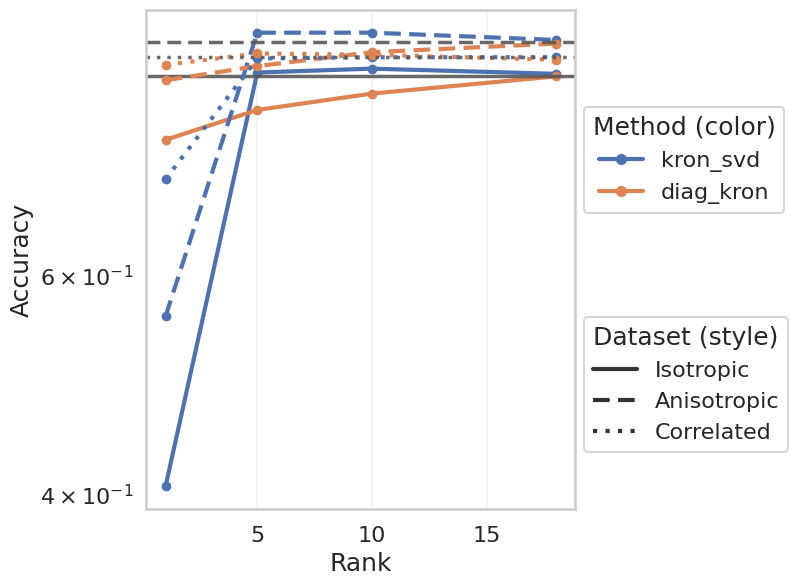

In [26]:
plot_compression_results_oneplot(resulting_df, savepath="accuracy.pdf")

In [25]:
!rm -rf grads_dump_batches

XF shape: (20, 20)
YF shape: (32, 32)

XF is almost diagonal: True (off-diag/diag ratio: 0.0000)
YF is almost diagonal: True (off-diag/diag ratio: 0.0000)


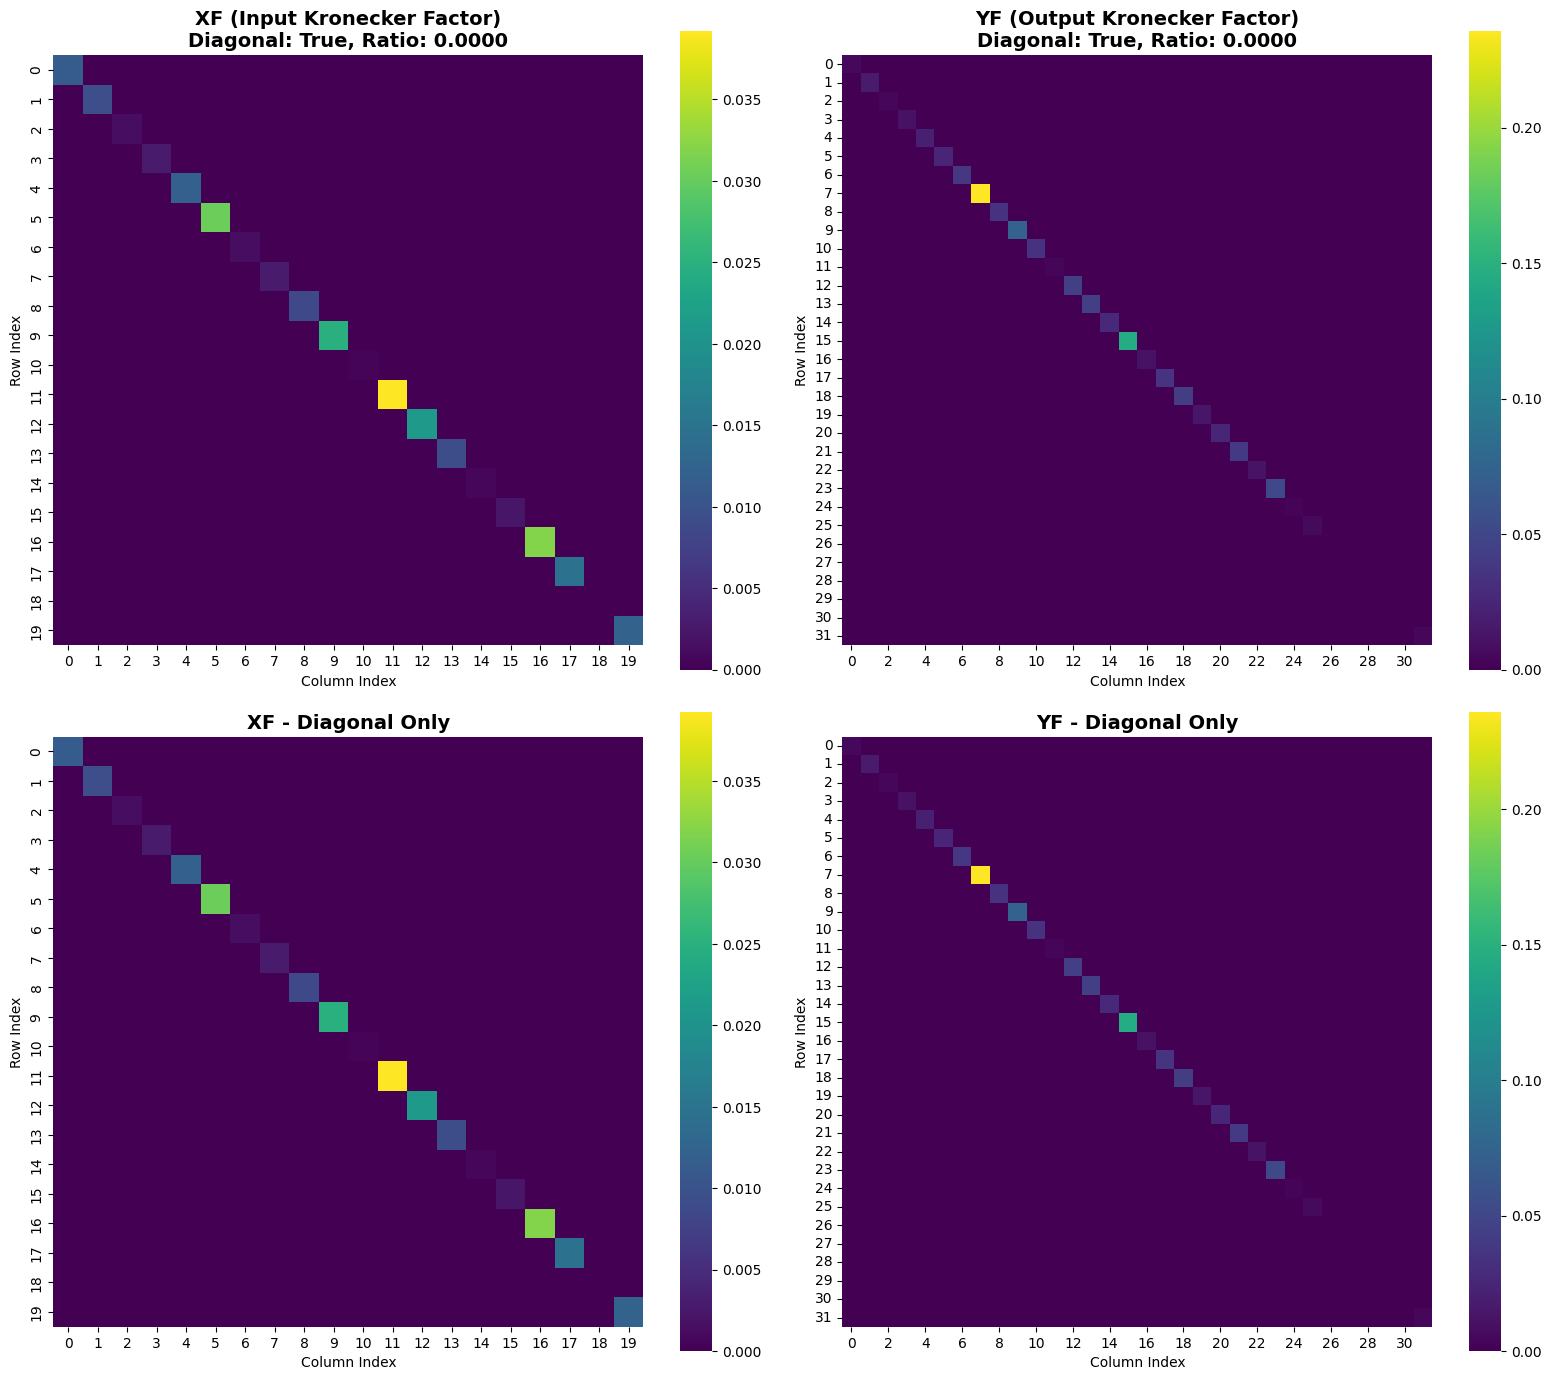


XF statistics:
  Diagonal mean: 0.0118
  Diagonal std:  0.0115
  Max off-diag:  0.0000

YF statistics:
  Diagonal mean: 0.0313
  Diagonal std:  0.0463
  Max off-diag:  0.0000


In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Load the files
XF_loaded = np.load('XF_reg.npy')
YF_loaded = np.load('YF_reg.npy')


print("XF shape:", XF_loaded.shape)
print("YF shape:", YF_loaded.shape)


# Check diagonality
def is_almost_diagonal(A, threshold=0.1):
    """Check if matrix is approximately diagonal"""
    diag_elements = np.diag(A)
    off_diag = A - np.diag(diag_elements)
    diag_norm = np.linalg.norm(diag_elements)
    off_diag_norm = np.linalg.norm(off_diag, 'fro')
    ratio = off_diag_norm / (diag_norm + 1e-10)
    return ratio < threshold, ratio


is_diag_XF, ratio_XF = is_almost_diagonal(XF_loaded)
is_diag_YF, ratio_YF = is_almost_diagonal(YF_loaded)


print(f"\nXF is almost diagonal: {is_diag_XF} (off-diag/diag ratio: {ratio_XF:.4f})")
print(f"YF is almost diagonal: {is_diag_YF} (off-diag/diag ratio: {ratio_YF:.4f})")


# Create figure with four subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))


# Heatmap for XF
sns.heatmap(XF_loaded, ax=axes[0, 0], cmap='viridis', cbar=True, square=True)
axes[0, 0].set_title(f'XF (Input Kronecker Factor)\nDiagonal: {is_diag_XF}, Ratio: {ratio_XF:.4f}', 
                     fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Column Index')
axes[0, 0].set_ylabel('Row Index')


# Heatmap for YF
sns.heatmap(YF_loaded, ax=axes[0, 1], cmap='viridis', cbar=True, square=True)
axes[0, 1].set_title(f'YF (Output Kronecker Factor)\nDiagonal: {is_diag_YF}, Ratio: {ratio_YF:.4f}', 
                     fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Column Index')
axes[0, 1].set_ylabel('Row Index')


# Show only diagonal of XF
XF_diag_only = np.diag(np.diag(XF_loaded))
sns.heatmap(XF_diag_only, ax=axes[1, 0], cmap='viridis', cbar=True, square=True)
axes[1, 0].set_title('XF - Diagonal Only', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Column Index')
axes[1, 0].set_ylabel('Row Index')


# Show only diagonal of YF
YF_diag_only = np.diag(np.diag(YF_loaded))
sns.heatmap(YF_diag_only, ax=axes[1, 1], cmap='viridis', cbar=True, square=True)
axes[1, 1].set_title('YF - Diagonal Only', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Column Index')
axes[1, 1].set_ylabel('Row Index')


plt.tight_layout()
plt.savefig('kronecker_factors_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()


# Additional statistics
print(f"\nXF statistics:")
print(f"  Diagonal mean: {np.mean(np.diag(XF_loaded)):.4f}")
print(f"  Diagonal std:  {np.std(np.diag(XF_loaded)):.4f}")
print(f"  Max off-diag:  {np.max(np.abs(XF_loaded - np.diag(np.diag(XF_loaded)))):.4f}")

print(f"\nYF statistics:")
print(f"  Diagonal mean: {np.mean(np.diag(YF_loaded)):.4f}")
print(f"  Diagonal std:  {np.std(np.diag(YF_loaded)):.4f}")
print(f"  Max off-diag:  {np.max(np.abs(YF_loaded - np.diag(np.diag(YF_loaded)))):.4f}")


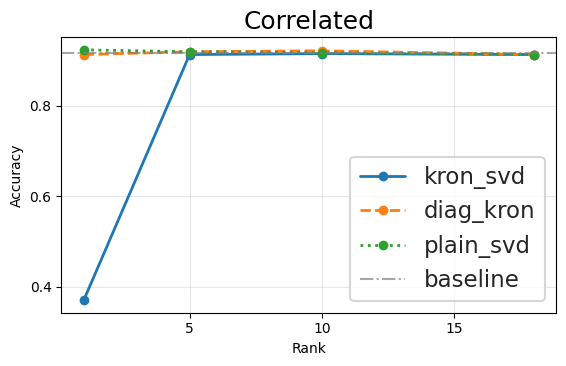

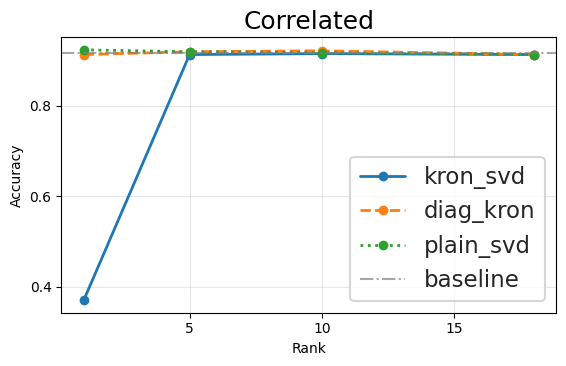

In [22]:
df = pd.read_csv("results_Correlated_fc1.csv") # n_samples = 4200
plot_compression_results(df)

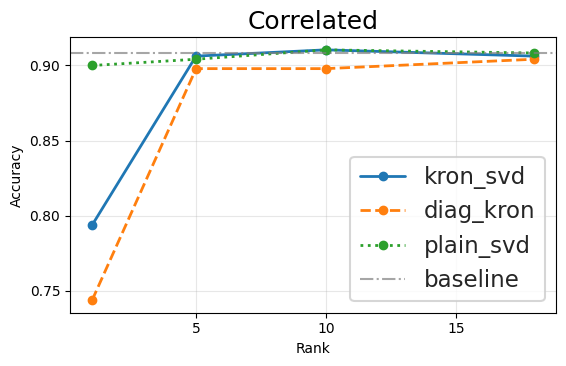

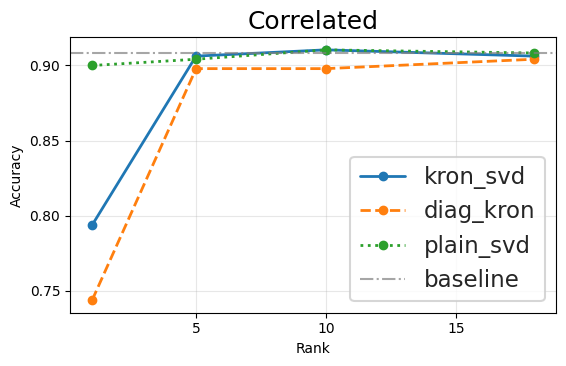

In [18]:
df = pd.read_csv("results_Correlated_fc1.csv") # n_samples = 4200
plot_compression_results(df)

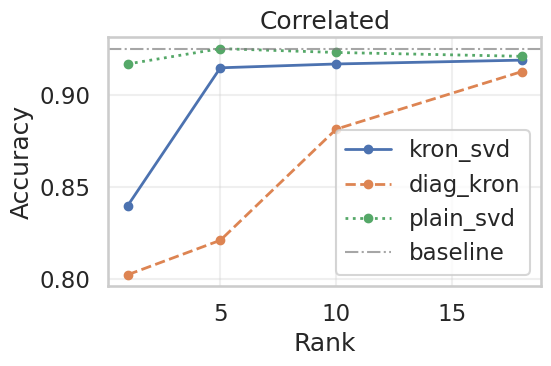

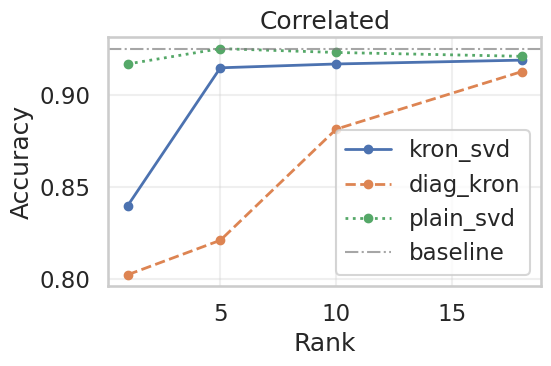

In [26]:
df = pd.read_csv("results_Correlated_fc1.csv") # n_samples = 4200
plot_compression_results(df)

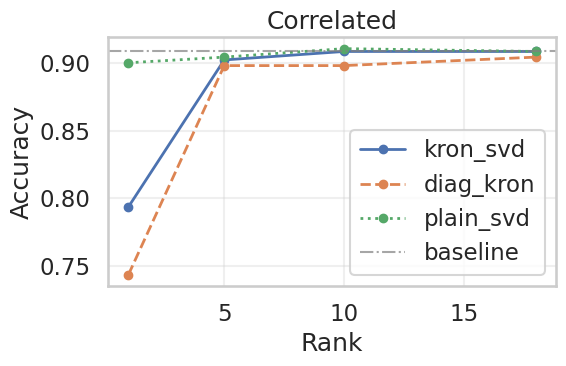

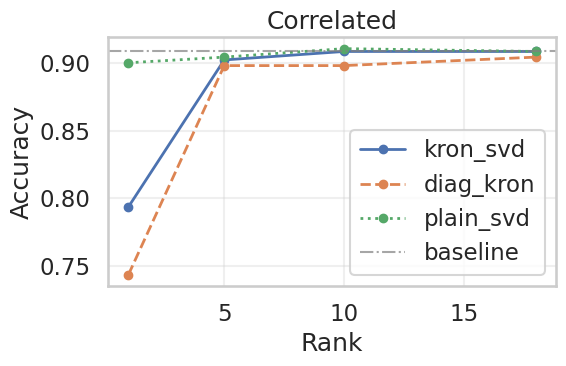

In [28]:
df = pd.read_csv("results_Correlated_fc1.csv") # n_samples = 3200
plot_compression_results(df)

# df = pd.read_csv("results_Anisotropic_fc1.csv")
# plot_compression_results(df)

# df = pd.read_csv("results_Isotropic_fc1.csv")
# plot_compression_results(df)

## Run for all seeds

In [ ]:
from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader

def run_all_seeds(
    seeds,
    datasets,
    model_type="TwoLayerMLP",
    target_layer="fc1",
    ranks=(1, 5, 10, 15),
    n_samples=3200,
    in_dim=20,
    hidden_dim=32,
    batch_size=20,
    val_split=0.2,
    lr=0.01,
    epochs=60,
    device=torch.device("cpu"),
    root_grads="./grads_dump_batches",
    use_last_n_batches=60,
):
    all_dfs = []

    for seed in seeds:
        # Global seeding (python/numpy/torch)
        seed_everything(seed, deterministic=True)  # defined in your notebook [file:43]

        for ds_name, ds_class in datasets.items():
            # Dataset seed: you can tie it to `seed` so each run is fully different
            ds = ds_class(n_samples=n_samples, in_dim=in_dim, seed=seed)  # note: your class uses nsamples/indim [file:43]
            X, y = ds.create_data()  # in your notebook it's createdata() [file:43]
            X = torch.as_tensor(X, dtype=torch.float32)

            val_split = 0.15
            calib_split = 0.15
            
            n_val = int(n_samples * val_split)
            n_calib = int(n_samples * calib_split)
            n_train = n_samples - n_val - n_calib
            
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            X_train = X_shuffled[:n_train]
            y_train = y_shuffled[:n_train]
            
            X_calib = X_shuffled[n_train : n_train + n_calib]
            y_calib = y_shuffled[n_train : n_train + n_calib]
            
            X_val = X_shuffled[n_train + n_calib:]
            y_val = y_shuffled[n_train + n_calib:]

            train_loader = DataLoader(TensorDataset(X_train, y_train),
                                      batch_size=batch_size, shuffle=False)
            val_loader = DataLoader(TensorDataset(X_val, y_val),
                                    batch_size=batch_size, shuffle=False)

            calib_loader = DataLoader(TensorDataset(X_calib, y_calib),
                                    batch_size=batch_size, shuffle=False)
            
            #if model_type == "TwoLayerMLP":
            #    model = TwoLayerMLP(in_dim=in_dim, hidden_dim=hidden_dim, out_dim=2)
            #else:
            #    model = OneLayerMLP(in_dim=in_dim, out_dim=2)

            # Put seed in output paths to avoid overwriting
            grads_dir = Path(root_grads) / f"seed_{seed}" / ds_name
            grads_dir.mkdir(parents=True, exist_ok=True)

            # 1) Train + dump grads
            #train(
            #    model=model,
            #    loader=train_loader,
            #    epochs=epochs,
            #    lr=lr,
            #    out_dir=grads_dir,
            #    device=device,
            #)  # [file:43]

            dump_grads_per_batch(
            model=model,
            loader=calib_loader,
            epochs=1,
            lr=1e-6,
            out_dir=grads_dir,
            device=device,
            )

            # 2) Compression experiment
            df = run_compression_experiment(
                trained_model=model,
                ds_name=ds_name,
                val_loader=val_loader,
                model_class=TwoLayerMLP if model_type == "TwoLayerMLP" else OneLayerMLP,
                target_layer=target_layer,
                ranks=list(ranks),
                grads_dir=grads_dir,
                device=device,
                use_last_n_batches=use_last_n_batches,
            )  # [file:43]

            df["seed"] = seed
            all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)

# Usage
datasets = {
    "Isotropic": IsotropicDataset,
    "Anisotropic": AnisotropicDataset,
    "Correlated": CorrelatedToeplitzDataset,
}

resulting_df = run_all_seeds(
    seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    datasets=datasets,
    model_type="TwoLayerMLP",
    target_layer="fc1",
    device=torch.device("cpu"),
)


Directory grads_dump_batches/seed_0/Isotropic was cleared.


g0.shape (32, 20)
s[0], s[1] 0.16037624 0.14240049
svd here
W1 shape, W2 shape (1, 20) (32, 1)
svd here
W1 shape, W2 shape (5, 20) (32, 5)
svd here
W1 shape, W2 shape (10, 20) (32, 10)
svd here
W1 shape, W2 shape (15, 20) (32, 15)
Directory grads_dump_batches/seed_0/Anisotropic was cleared.
g0.shape (32, 20)
s[0], s[1] 0.7572459 0.69229406
svd here
W1 shape, W2 shape (1, 20) (32, 1)
svd here
W1 shape, W2 shape (5, 20) (32, 5)
svd here
W1 shape, W2 shape (10, 20) (32, 10)
svd here
W1 shape, W2 shape (15, 20) (32, 15)
Directory grads_dump_batches/seed_0/Correlated was cleared.
g0.shape (32, 20)
s[0], s[1] 1.6654705 1.6208224
svd here
W1 shape, W2 shape (1, 20) (32, 1)
svd here
W1 shape, W2 shape (5, 20) (32, 5)
svd here
W1 shape, W2 shape (10, 20) (32, 10)
svd here
W1 shape, W2 shape (15, 20) (32, 15)
Directory grads_dump_batches/seed_1/Isotropic was cleared.
g0.shape (32, 20)
s[0], s[1] 0.24206737 0.18697208
svd here
W1 shape, W2 shape (1, 20) (32, 1)
svd here
W1 shape, W2 shape (5, 20)

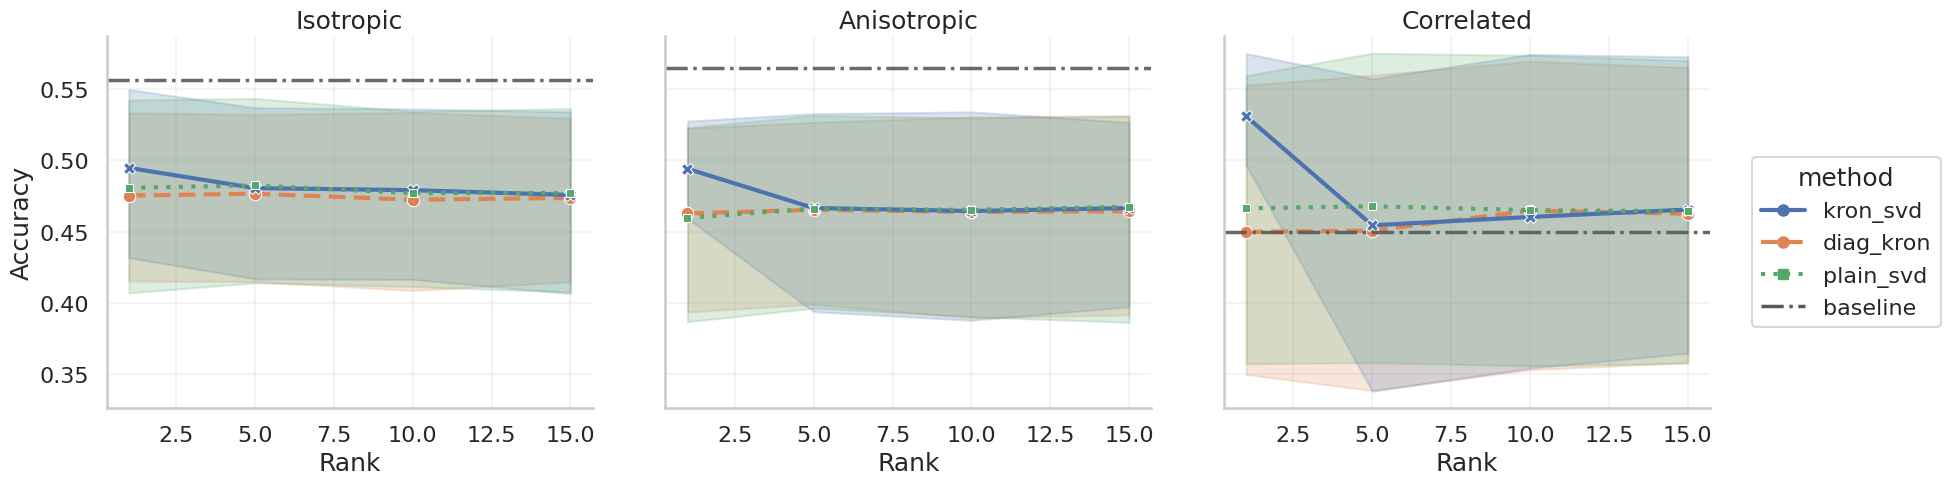

In [29]:
# calib bs = 16
g = plot_compression_results_sns(
    resulting_df,
    # savepath=Path(""),
    # ci="sd",            # std band across seeds (if seed column exists)
)

In [24]:
!pwd

/home/jovyan/shares/SR004.nfs2/chekalina/FisherKronecker/anisotropic_dataset


Saving plot to: /home/jovyan/shares/SR004.nfs2/chekalina/FisherKronecker/anisotropic_dataset/plots/compression_grid.png


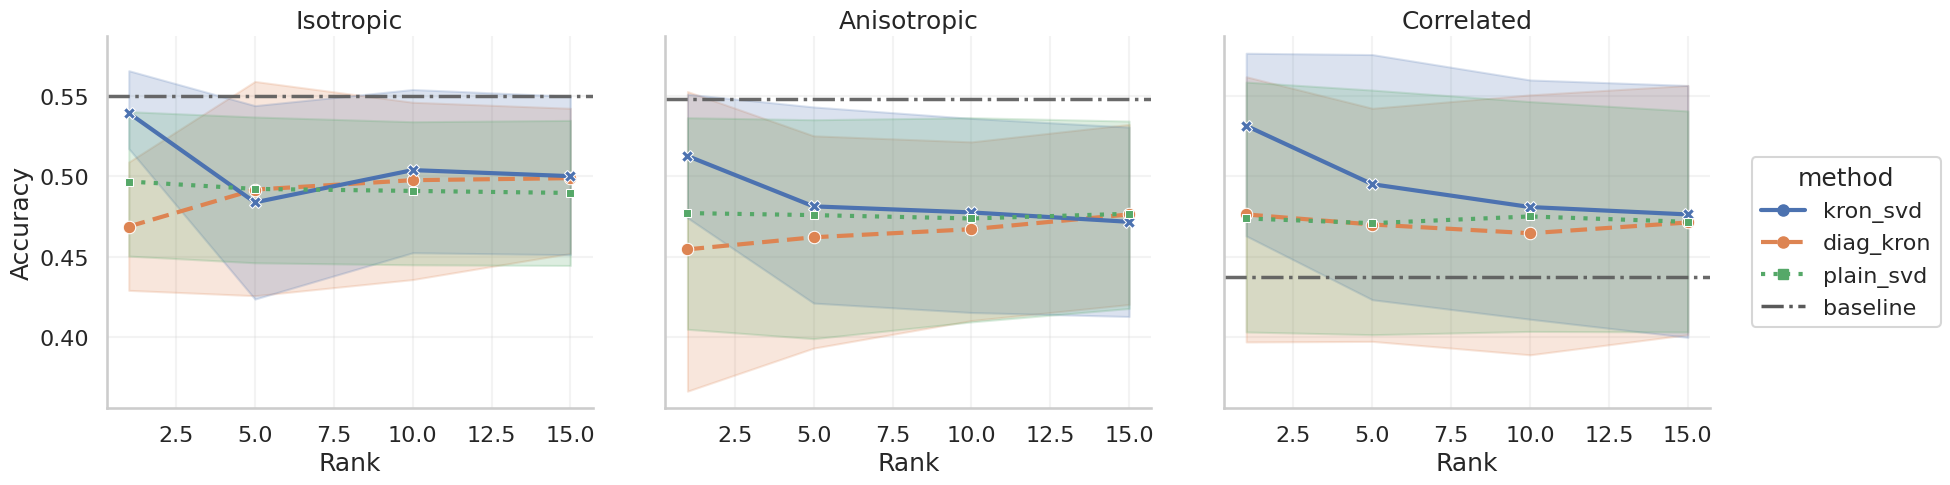

In [27]:
# calib bs = 32
g = plot_compression_results_sns(
    resulting_df,
    savepath=Path("/home/jovyan/shares/SR004.nfs2/chekalina/FisherKronecker/anisotropic_dataset/plots/compression_grid.png"),
    # ci="sd",            # std band across seeds (if seed column exists)
)

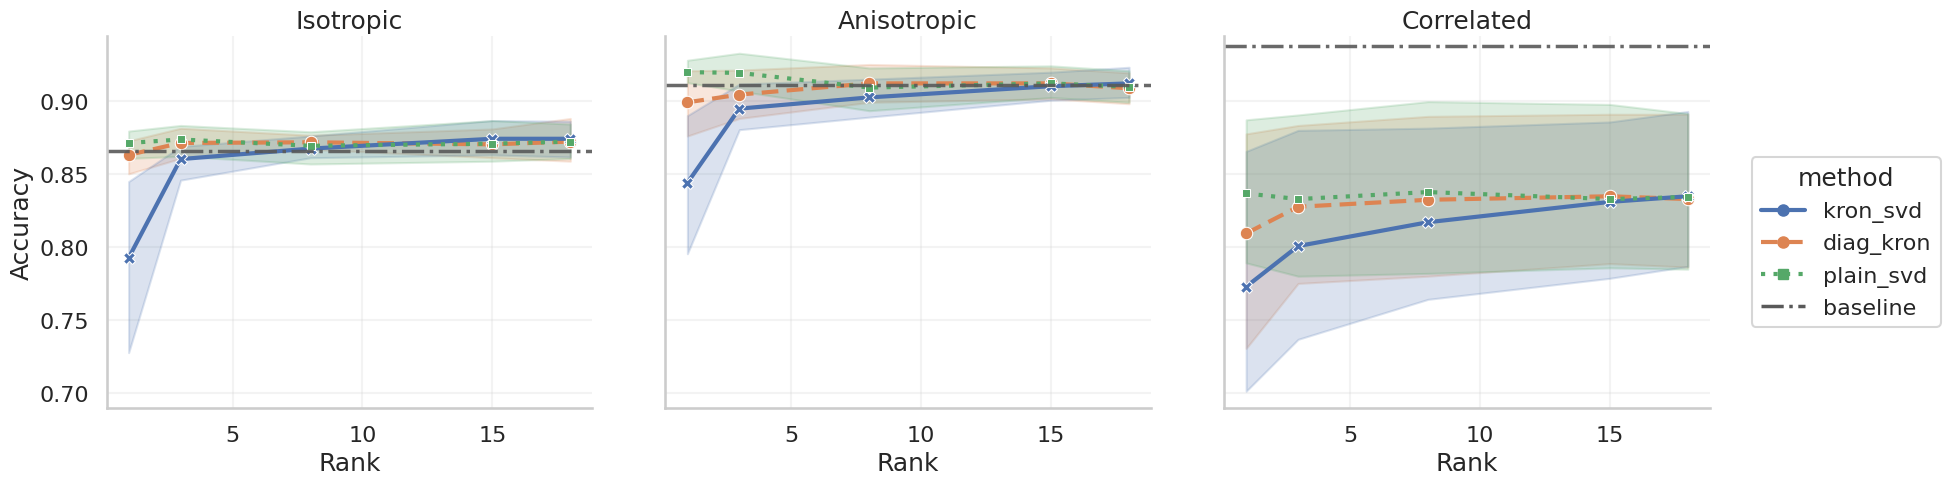

In [118]:
g = plot_compression_results_sns(
    resulting_df,
    savepath=Path("./plots/compression_grid.png"),
    # ci="sd",            # std band across seeds (if seed column exists)
)